## GRID WORLD
#### Implementing a grid world MDP from sutton and applying policy and value iterations to it.


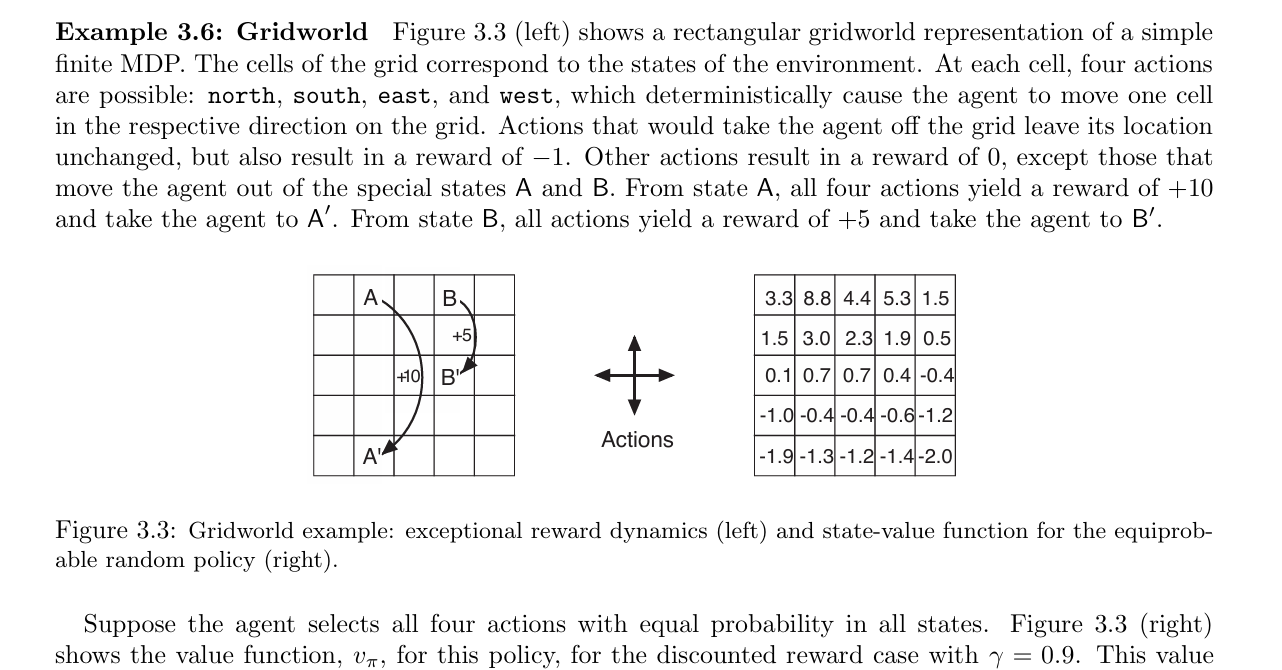

In [1]:
import numpy as np

In [ ]:
"""
pi1: every action from every state is equally probable
NOTE: that the policy given above is stochastic while the envionment is deterministic.
"""

# Constants
grid_size = (5, 5)
gamma = 0.9  # discount factor
actions = {'N': (-1, 0), 'S': (1, 0), 'E': (0, 1), 'W': (0, -1)}
action_list = list(actions.keys())

# Special states
A = (0, 1)
A_prime = (4, 1)
B = (0, 3)
B_prime = (2, 3)

# Rewards
reward_A = 10
reward_B = 5
step_penalty = 0
off_grid_penalty = -1

In [16]:
# transition function
def next_reward(state, action):
    if state==A:
        return A_prime, reward_A
    elif state==B:
        return B_prime, reward_B
    
    move=actions[action]
    new_state=(state[0]+move[0], state[1]+move[1])
    
    if new_state[0]<0 or new_state[0]>=grid_size[0] or new_state[1]<0 or new_state[1]>=grid_size[1]: 
        return state, off_grid_penalty
    
    return new_state, step_penalty

In [ ]:
# policy evaluation for given policy pi1
def policy_eval(grid_size, gamma, iterations=100):
    V=np.zeros(grid_size)
    
    for _ in range(iterations):
        new_v=np.zeros(grid_size)
        for i in range(grid_size[0]):
            for j in range(grid_size[1]):
                
                for action in action_list:
                    (ni,nj), reward=next_reward((i,j), action)
                    new_v[i,j]=new_v[i,j]+ .25*(reward+gamma*V[ni,nj])
        
        V=new_v
    return V

In [34]:
V=policy_eval(grid_size, gamma)
np.set_printoptions(precision=1, suppress=True)
print(V)

[[ 3.3  8.8  4.4  5.3  1.5]
 [ 1.5  3.   2.3  1.9  0.5]
 [ 0.1  0.7  0.7  0.4 -0.4]
 [-1.  -0.4 -0.4 -0.6 -1.2]
 [-1.9 -1.3 -1.2 -1.4 -2. ]]


In [ ]:
# value iteration to find optimal policy
def val_iter(grid_size, gamma, iterations=100):
    V=np.zeros(grid_size)
    
    for _ in range(iterations):
        new_v=np.zeros(grid_size)
        for i in range(grid_size[0]):
            for j in range(grid_size[1]):
                
                for action in action_list:
                    (ni,nj), reward=next_reward((i,j), action)
                    new_v[i,j]=max(new_v[i,j], reward+gamma*V[ni, nj])
        V=new_v
    return V

In [ ]:
# we now obtain the values corresponding to each state in accordance with the optimal policy
# once optimal values for each state is obtained, optimal actions for each state can be choosen gredily
V_opt=val_iter(grid_size, gamma)    
np.set_printoptions(precision=1, suppress=True)
print(V_opt)

[[22.  24.4 22.  19.4 17.5]
 [19.8 22.  19.8 17.8 16. ]
 [17.8 19.8 17.8 16.  14.4]
 [16.  17.8 16.  14.4 13. ]
 [14.4 16.  14.4 13.  11.7]]
